In [22]:
import matplotlib.pyplot as plt
import igraph as ig
from igraph import Graph
from sklearn.metrics import mean_squared_error
from itertools import product
import pandas as pd
from collections import Counter

from PAMI.extras.stats import graphDatabase as alg
from PAMI.subgraphMining.basic import gspan as alg

### Other libraries
import warnings
warnings.filterwarnings('ignore')

## Functions and procedures

In [23]:
# Function for recovering CSV files for building SEASONS graph
# input: paths to edges and vertices files
# output: two dataframes containing vertices and edges

def read_files_season(path_edges, path_vertices):
    vertices = pd.read_csv(path_vertices,sep="\t")
    edges = pd.read_csv(path_edges,sep=";") 
    edges = edges.rename(columns={"gid_from":"source","gid_to":"target"})
    return vertices, edges

In [24]:
# Function for building a directed graph
# input: a dataframe of vertices and a dataframe of edges
# output: a directed graph

def building_graph_ig(vertices, edges):
    g = ig.Graph.DictList(
        vertices = vertices.to_dict('records'),
        edges = edges.to_dict('records'),
        directed = True,
        vertex_name_attr='id',
        #vertex_name_attr=vertices.index.values, 
        edge_foreign_keys=('source', 'target'))
    isolated = [v.index for v in g.vs if g.degree(v) == 0]
    g.delete_vertices(isolated)
    return g

In [25]:
# Function for deleting all isolated vertices and multiple arrays from and to the same vertices
# input: a graph
# output: the same graph without isolated vertices and simple edges
# Delete all self-loops edges like (0,0) and join all edges in one, e.g., (0,1) 18 is now (0,1) 1
# 18 means it exist 18 relations between vertices 0 and 1

def graph_simplify(g):
    g_sim = g.copy()
    return g_sim.simplify(loops=True, multiple=True)

In [26]:
# Function for showing stats of a graph
# input: a graph (igraph)
# output: stats

def graph_stats(G):
    num_nodes = G.vcount()
    num_edges = G.ecount()
    num_loops = sum(1 for e in G.es if e.source == e.target)
    return num_nodes, num_edges, num_loops

In [27]:
# Function for creating a txt file storing multiple graphs
# input: a list of graphs, the output file name
# output: a dictionary {graph_idx: {internal_id: original_id}} and a .txt file

# "t # N"** means that the encoding of the *Nth* graph begins
# "v M L"** means that the *M-th* vertex in this graph has label *L*
# "e P Q L"** means that there is an edge connecting vertex *P* to vertex *Q*. This edge is labeled *L*

def create_graph_gspan(graphs, output_filename):
    mapping = {}
    with open(output_filename, 'w') as f:
        for g_idx, g in enumerate(graphs):
            mapping[g_idx] = {}
            f.write(f"t # {g_idx}\n")
            
            # Asignación de nuevos números a los vértices y creación del mapeo.
            for new_id, vertex in enumerate(g.vs):
                orig_id = vertex['id']  # Se asume que el atributo 'id' contiene el ID original.
                mapping[g_idx][new_id] = orig_id
                f.write(f"v {new_id} " + str(orig_id) + " \n")
            
            # Escritura de las aristas utilizando los nuevos números.
            for edge in g.es:
                src, tgt = edge.tuple
                f.write(f"e {src} {tgt} 1\n")
    return mapping

In [28]:
# Function mapping a graph using a dictionary
# input: a list of graphs
# output: a dictionary

def mapping_graphs(graphs):

    id_mapping = {}  # Dictionary for storing mappings {graph_idx: {internal_id: original_id}}
    for i, graph in enumerate(graphs):
        id_mapping[i] = {v.index: v["id"] for v in graph.vs} 
    
    return id_mapping

In [29]:

# Execute the gSpan algorith on a .TXT file containing the igraph.Graph objects
# input: minimal support, the imput file name (graphs), the output file name (patterns) and max size of patterns
# output: a list of frequent subgraphs and a .txt file containing the patterns

def subgraph_pattens_mining(minSup, input_filename, output_filename, max_size_patt):
    obj = alg.GSpan(input_filename, minSup, outputSingleVertices=False, maxNumberOfEdges=max_size_patt)
    #obj = alg.GSpan(input_filename, minSup, outputSingleVertices=False, maxNumberOfEdges=max_size_patt, outputGraphIds=True)
    obj.mine()
    frequentGraphs = obj.getFrequentSubgraphs()
    obj.save(output_filename)
    return frequentGraphs

## Recovering data and buidling graphs

In [30]:
### Data recovering and graph buiding

edges_file = "MEL_circulationGraph_0.csv"
vertices_file = "MEL_tripLocation.csv"
vertices, edges = read_files_season(edges_file, vertices_file)
vertices.rename(columns={"gid": "id"}, inplace=True)
vertices['id_aux'] = vertices.reset_index().index # +1 for starting from 1

In [31]:
vertices.head()

,id,idTrip,fromId,nom,url,rating,nbAvis,nbAvisRecupere,latitude,longitude,...,ap_inclusions,ap_introduction,ap_primary_supplier_attraction_id,ap_primary_supplier_subtype,ap_primary_ta_geo_id,ap_product_code,ap_product_highlights,ap_product_text,ap_raw,id_aux
0,196911,187178.0,NaN,Novotel Lille Centre Grand Place,NaN,3.803971,1211,1211.0,50.636734,3.058971,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,196912,187178.0,NaN,Mercure Lille Centre Grand Place,NaN,3.860473,1432,1432.0,50.638170,3.065553,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,196913,196637.0,NaN,Mercure Lille Roubaix Grand Hotel,NaN,3.749784,424,425.0,50.692260,3.172287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,196916,187178.0,NaN,Ibis Lille Centre Gares,NaN,3.783941,1063,1063.0,50.634690,3.070875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,196917,187178.0,NaN,Ibis Styles Lille Centre Gare Beffroi,NaN,3.433585,1303,1303.0,50.632520,3.067851,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4


In [32]:
edges.head()

,source,target,year,month,country,age,NbPerMaxDurationDays_1,NbPerMaxDurationDays_3,NbPerMaxDurationDays_5,NbPerMaxDurationDays_7,NbPerMaxDurationDays_14,NbPerMaxDurationDays_inf
0,7174290,8079112,2018,0,Italy,-,2,2,2,2,2,2
1,7174290,7249027,2019,0,France,-,1,1,1,1,1,1
2,7174290,3722878,2015,0,The Netherlands,-,1,1,1,1,1,1
3,7174290,3784521,2017,0,The Netherlands,-,0,0,0,1,1,1
4,7174290,8453765,2017,0,Canada,-,1,1,1,1,1,1


In [33]:
### Show unique values of year feature

edges["year"].unique

<bound method Series.unique of 0        2018
1        2019
2        2015
3        2017
4        2017
         ... 
94824    2016
94825    2017
94826    2018
94827    2016
94828    2017
Name: year, Length: 94829, dtype: int64>

In [34]:
### Selecting edges using a specific year

edges_2015 = edges[edges['year'] == 2015]
edges_2016 = edges[edges['year'] == 2016]

In [35]:
### Creating a big graph (all years)

big_graph = building_graph_ig(vertices, edges)
gi = graph_simplify(big_graph.copy())

In [36]:
### Creating graph for a specific year

graph_2015 = building_graph_ig(vertices, edges_2015)
gi_2015 = graph_simplify(graph_2015)
graph_2016 = building_graph_ig(vertices, edges_2016)
gi_2016 = graph_simplify(graph_2016)

In [37]:
### Comparing 2 graphs (with and without loops and double edges)

stats_A = graph_stats(big_graph)
stats_B = graph_stats(gi)

print("Graph A (multigraph):")
print(f"  Nodes: {stats_A[0]}")
print(f"  Edges: {stats_A[1]}")
print(f"  Self-loops: {stats_A[2]}")

print("\nGraph B (simplified):")
print(f"  Nodes: {stats_B[0]}")
print(f"  Edges: {stats_B[1]}")
print(f"  Self-loops: {stats_B[2]}")

Graph A (multigraph):
  Nodes: 2746
  Edges: 94829
  Self-loops: 3799

Graph B (simplified):
  Nodes: 2746
  Edges: 62164
  Self-loops: 0


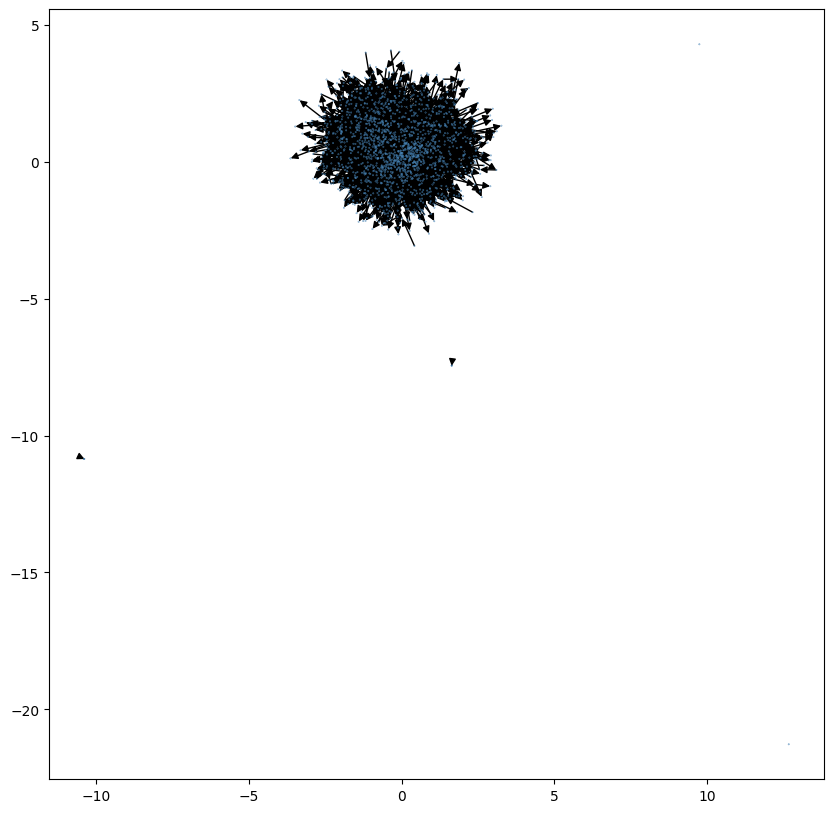

In [38]:
### Ploting a graph using i-graph library

from igraph import plot

layout = gi_2015.layout("fr")  # "fr" = Fruchterman-Reingold (fuerza)
fig, ax = plt.subplots(figsize=(10,10))
plot(gi_2015, target=ax, layout=layout, vertex_size=0.3)
plt.show()

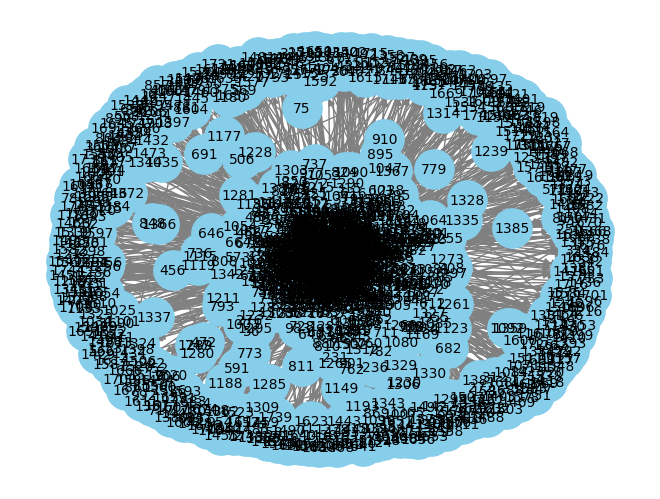

In [39]:
### Ploting a graph using networkx library

import networkx as nx
G_nx = gi_2015.to_networkx()
pos = nx.spring_layout(G_nx, seed=42)  # layout por fuerza
nx.draw(
    G_nx,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=800,
    font_size=10,
    font_color="black",
    edge_color="gray"
)

plt.show()

## Extracting frequent sub-graphs

In [40]:
# We create a list of graphs
lst_graphs = [gi_2015, gi_2016]
#id_mapping = mapping_graphs(lst_graphs) # not necessary

In [41]:
# Here we create a file for storing the graphs in specific format for gspam algorithm

graphs_gspan_in_filename = "graphs_gspam.txt"
mapping = create_graph_gspan(lst_graphs, graphs_gspan_in_filename)

In [42]:
# Here we extract frequent sub graphs and store them into a txt file following the same format of gspan
# We need a minimal support and a max size

graphs_gspan_out_filename = 'frequentSubgraphs.txt'
minSup = 0.9
max_size_patt = 3
subgraph_pattens = subgraph_pattens_mining(minSup, graphs_gspan_in_filename, graphs_gspan_out_filename, max_size_patt)